# FAR-Trans — EDA Dashboard sau khi làm sạch

Notebook này dùng để:
- Thống kê tổng số khách hàng, tài sản, giao dịch và thị trường.
- Kiểm tra dữ liệu thiếu, trùng và độ phủ dữ liệu.
- Phân tích khách hàng theo loại, mức rủi ro và khả năng đầu tư.
- Phân tích tài sản theo loại, ngành và thị trường.
- Phân tích giao dịch Buy/Sell, kênh và giá trị giao dịch.
- So sánh các split train/test.
- Xuất bảng CSV, biểu đồ PNG và báo cáo Excel vào `eda_output`.


In [11]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# SỬA ĐƯỜNG DẪN NÀY
DATA_DIR = Path("/Users/meomeo/Downloads/Thesis/output")
CLEAN_DIR = DATA_DIR / "cleaned"
OUTPUT_DIR = DATA_DIR / "eda_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder :", DATA_DIR.resolve())
print("Output folder:", OUTPUT_DIR.resolve())


Data folder : /Users/meomeo/Downloads/Thesis/output
Output folder: /Users/meomeo/Downloads/Thesis/output/eda_output


## 1. Đọc dữ liệu đã làm sạch

In [12]:
files = {
    "customers": CLEAN_DIR / "customer_information_clean.csv",
    "assets": CLEAN_DIR / "asset_information_clean.csv",
    "markets": CLEAN_DIR / "markets_clean.csv",
    "prices": CLEAN_DIR / "close_prices_clean.csv",
    "limit_prices": CLEAN_DIR / "limit_prices_clean.csv",
    "transactions": CLEAN_DIR / "transactions_clean.csv",
}

missing = [str(p) for p in files.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Không tìm thấy:\n" + "\n".join(missing))

customers = pd.read_csv(files["customers"], parse_dates=["lastQuestionnaireDate", "timestamp"])
assets = pd.read_csv(files["assets"], parse_dates=["timestamp"])
markets = pd.read_csv(files["markets"])
prices = pd.read_csv(files["prices"], parse_dates=["timestamp"])
limit_prices = pd.read_csv(files["limit_prices"], parse_dates=["minDate", "maxDate"])
transactions = pd.read_csv(files["transactions"], parse_dates=["timestamp"])

datasets = {
    "customer_information": customers,
    "asset_information": assets,
    "markets": markets,
    "close_prices": prices,
    "limit_prices": limit_prices,
    "transactions": transactions,
}

for name, df in datasets.items():
    print(f"{name:25s}: {len(df):,} dòng × {df.shape[1]} cột")


customer_information     : 32,468 dòng × 8 cột
asset_information        : 836 dòng × 9 cột
markets                  : 38 dòng × 8 cột
close_prices             : 703,303 dòng × 3 cột
limit_prices             : 807 dòng × 6 cột
transactions             : 359,128 dòng × 9 cột


## 2. Dashboard tổng quan

In [13]:
customer_latest = customers.sort_values("timestamp").drop_duplicates("customerID", keep="last").copy()
asset_latest = assets.sort_values("timestamp").drop_duplicates("ISIN", keep="last").copy()

overview = pd.DataFrame({
    "Chỉ số": [
        "Số khách hàng duy nhất",
        "Số tài sản duy nhất",
        "Số thị trường",
        "Tổng số giao dịch",
        "Số giao dịch Buy",
        "Số giao dịch Sell",
        "Tổng giá trị giao dịch",
        "Giá trị giao dịch trung bình",
        "Ngày giao dịch đầu tiên",
        "Ngày giao dịch cuối cùng",
    ],
    "Giá trị": [
        customer_latest["customerID"].nunique(),
        asset_latest["ISIN"].nunique(),
        markets["marketID"].nunique(),
        len(transactions),
        (transactions["transactionType"] == "Buy").sum(),
        (transactions["transactionType"] == "Sell").sum(),
        transactions["totalValue"].sum(),
        transactions["totalValue"].mean(),
        transactions["timestamp"].min(),
        transactions["timestamp"].max(),
    ]
})
display(overview)
overview.to_csv(OUTPUT_DIR / "01_overview.csv", index=False)


,Chỉ số,Giá trị
0,Số khách hàng duy nhất,29090
1,Số tài sản duy nhất,806
2,Số thị trường,38
3,Tổng số giao dịch,359128
4,Số giao dịch Buy,213639
5,Số giao dịch Sell,145489
6,Tổng giá trị giao dịch,"3,033,565,914.75"
7,Giá trị giao dịch trung bình,"8,447.03"
8,Ngày giao dịch đầu tiên,2018-01-02 00:00:00
9,Ngày giao dịch cuối cùng,2022-11-30 00:00:00


## 3. Chất lượng dữ liệu

In [14]:
quality = []
missing_cols = []

for name, df in datasets.items():
    total = df.shape[0] * df.shape[1]
    missing_cells = int(df.isna().sum().sum())
    quality.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": missing_cells,
        "missing_percent": 100 * missing_cells / total if total else 0,
    })
    for col in df.columns:
        n = int(df[col].isna().sum())
        if n:
            missing_cols.append({
                "dataset": name,
                "column": col,
                "missing_count": n,
                "missing_percent": 100 * n / len(df)
            })

quality_summary = pd.DataFrame(quality)
missing_by_column = pd.DataFrame(missing_cols)

display(quality_summary)
display(missing_by_column)

quality_summary.to_csv(OUTPUT_DIR / "02_data_quality_summary.csv", index=False)
missing_by_column.to_csv(OUTPUT_DIR / "03_missing_by_column.csv", index=False)


,dataset,rows,columns,duplicate_rows,missing_cells,missing_percent
0,customer_information,32468,8,0,0,0.00
1,asset_information,836,9,0,1121,14.90
2,markets,38,8,0,1,0.33
3,close_prices,703303,3,0,0,0.00
4,limit_prices,807,6,0,0,0.00
5,transactions,359128,9,0,0,0.00


,dataset,column,missing_count,missing_percent
0,asset_information,assetName,24,2.87
1,asset_information,assetShortName,1,0.12
2,asset_information,assetSubCategory,269,32.18
3,asset_information,sector,388,46.41
4,asset_information,industry,439,52.51
5,markets,tradingHours,1,2.63


## 4. Phân bố khách hàng

In [15]:
def count_table(df, col, label):
    out = (
        df[col].fillna("Missing")
        .value_counts()
        .rename_axis(label)
        .reset_index(name="Số khách hàng")
    )
    out["Tỷ lệ (%)"] = out["Số khách hàng"] / out["Số khách hàng"].sum() * 100
    return out

customer_type = count_table(customer_latest, "customerType", "Loại khách hàng")
risk_level = count_table(customer_latest, "riskLevel", "Mức rủi ro")
capacity = count_table(customer_latest, "investmentCapacity", "Khả năng đầu tư")

display(Markdown("### Theo loại khách hàng"))
display(customer_type)
display(Markdown("### Theo mức rủi ro"))
display(risk_level)
display(Markdown("### Theo khả năng đầu tư"))
display(capacity)

customer_type.to_csv(OUTPUT_DIR / "04_customer_by_type.csv", index=False)
risk_level.to_csv(OUTPUT_DIR / "05_customer_by_risk.csv", index=False)
capacity.to_csv(OUTPUT_DIR / "06_customer_by_capacity.csv", index=False)


### Theo loại khách hàng

,Loại khách hàng,Số khách hàng,Tỷ lệ (%)
0,Mass,18610,63.97
1,Premium,8906,30.62
2,Professional,1327,4.56
3,Inactive,208,0.72
4,Legal Entity,39,0.13


### Theo mức rủi ro

,Mức rủi ro,Số khách hàng,Tỷ lệ (%)
0,Income,11838,40.69
1,Balanced,8582,29.50
2,Conservative,5672,19.50
3,Aggressive,2678,9.21
4,Unknown,320,1.10


### Theo khả năng đầu tư

,Khả năng đầu tư,Số khách hàng,Tỷ lệ (%)
0,CAP_LT30K,17716,60.90
1,CAP_30K_80K,5483,18.85
2,CAP_80K_300K,4766,16.38
3,CAP_GT300K,802,2.76
4,Unknown,323,1.11


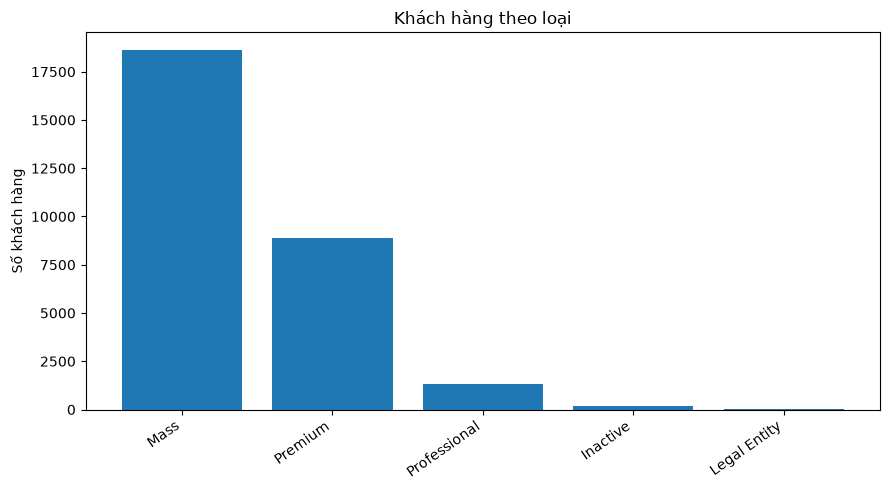

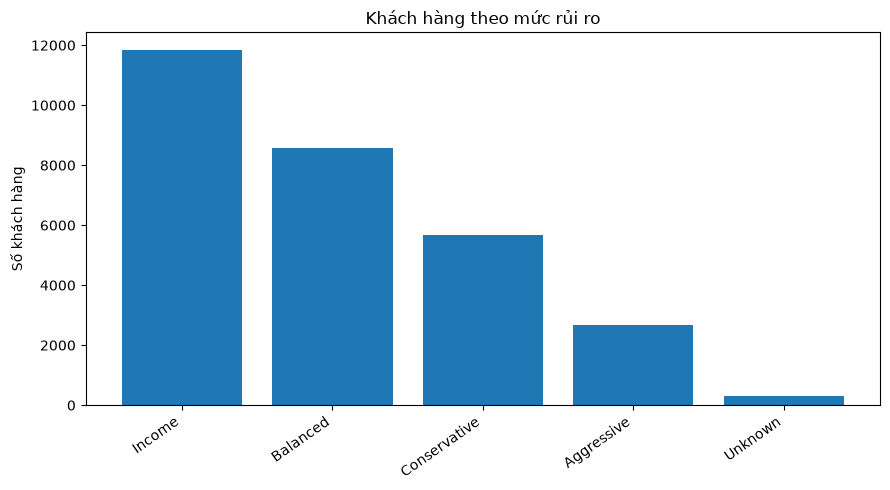

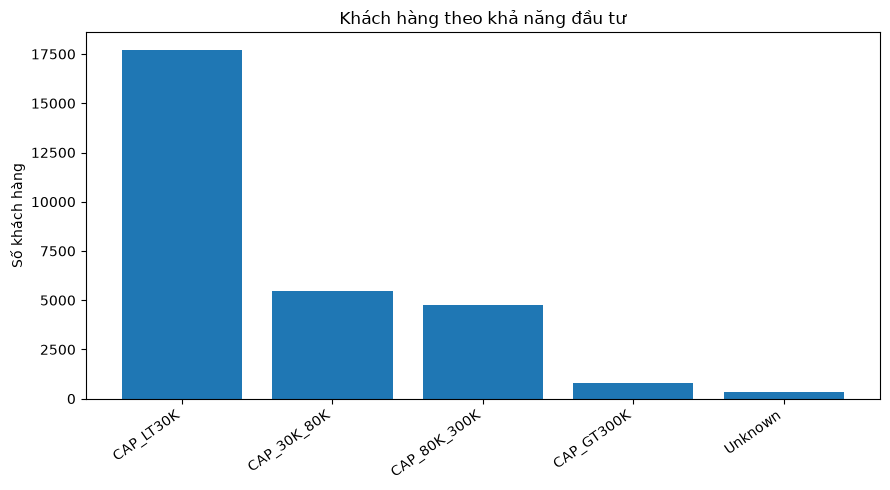

In [16]:
def bar_chart(df, x, y, title, file):
    plot_df = df.copy()

    plot_df[x] = (
        plot_df[x]
        .fillna("Unknown")
        .astype(str)
    )

    plot_df[y] = pd.to_numeric(
        plot_df[y],
        errors="coerce"
    ).fillna(0)

    plt.figure(figsize=(9, 5))
    plt.bar(
        plot_df[x].tolist(),
        plot_df[y].tolist()
    )

    plt.title(title)
    plt.ylabel(y)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / file,
        dpi=160,
        bbox_inches="tight"
    )
    plt.show()

bar_chart(customer_type, "Loại khách hàng", "Số khách hàng",
          "Khách hàng theo loại", "customer_by_type.png")
bar_chart(risk_level, "Mức rủi ro", "Số khách hàng",
          "Khách hàng theo mức rủi ro", "customer_by_risk.png")
bar_chart(capacity, "Khả năng đầu tư", "Số khách hàng",
          "Khách hàng theo khả năng đầu tư", "customer_by_capacity.png")


## 5. Phân bố tài sản

,assetCategory,Số tài sản,Tỷ lệ (%)
0,MTF,312,38.71
1,Stock,285,35.36
2,Bond,209,25.93


,sector,Số tài sản,Tỷ lệ (%)
0,NaN,382,47.39
1,Corporate,149,18.49
2,Sovereign,49,6.08
3,Industrials,44,5.46
4,Consumer Cyclical,41,5.09
5,Technology,26,3.23
6,Financial Services,24,2.98
7,Basic Materials,19,2.36
8,Consumer Defensive,18,2.23
9,Communication Services,13,1.61


,marketID,Số tài sản,Tỷ lệ (%)
0,XATH,213,26.43
1,XLUX,148,18.36
2,XNYS,87,10.79
3,XETR,81,10.05
4,CCLX,70,8.68
5,XLON,35,4.34
6,AEDAK,18,2.23
7,ENAX,18,2.23
8,XPAR,18,2.23
9,XBER,12,1.49


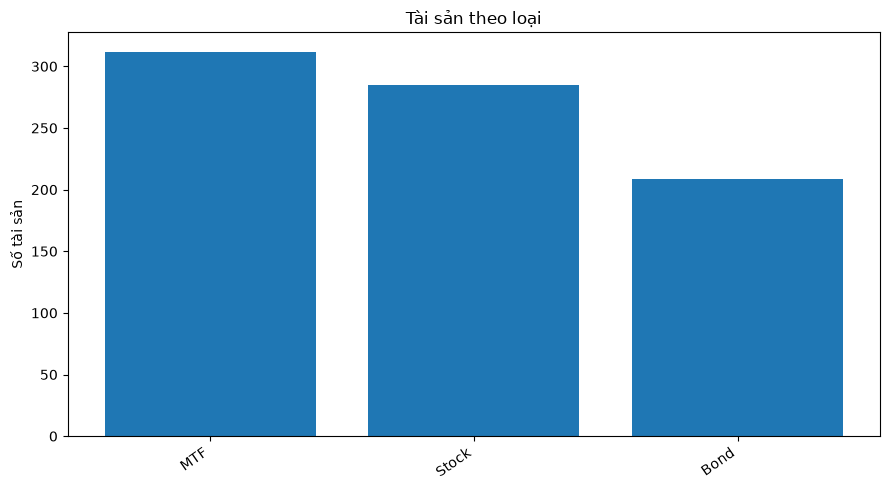

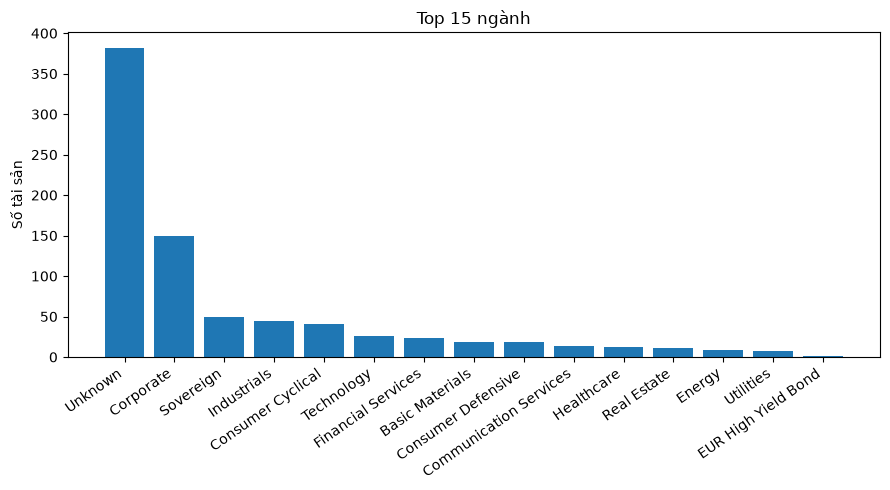

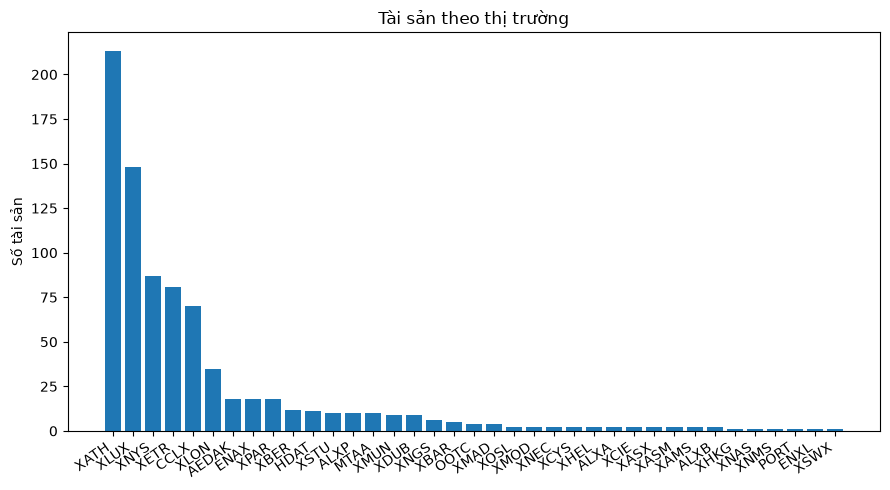

In [17]:
def asset_count(col):
    out = (
        asset_latest.groupby(col, dropna=False)["ISIN"]
        .nunique()
        .sort_values(ascending=False)
        .rename("Số tài sản")
        .reset_index()
    )
    out["Tỷ lệ (%)"] = out["Số tài sản"] / out["Số tài sản"].sum() * 100
    return out

asset_category = asset_count("assetCategory")
asset_sector = asset_count("sector")
asset_market = asset_count("marketID")

display(asset_category)
display(asset_sector.head(20))
display(asset_market)

asset_category.to_csv(OUTPUT_DIR / "07_asset_by_category.csv", index=False)
asset_sector.to_csv(OUTPUT_DIR / "08_asset_by_sector.csv", index=False)
asset_market.to_csv(OUTPUT_DIR / "09_asset_by_market.csv", index=False)

bar_chart(asset_category, "assetCategory", "Số tài sản",
          "Tài sản theo loại", "asset_by_category.png")
bar_chart(asset_sector.head(15), "sector", "Số tài sản",
          "Top 15 ngành", "asset_by_sector.png")
bar_chart(asset_market, "marketID", "Số tài sản",
          "Tài sản theo thị trường", "asset_by_market.png")


## 6. Phân tích giao dịch

In [18]:
transaction_type = (
    transactions["transactionType"].value_counts()
    .rename_axis("Loại giao dịch").reset_index(name="Số giao dịch")
)
transaction_type["Tỷ lệ (%)"] = transaction_type["Số giao dịch"] / len(transactions) * 100

transaction_channel = (
    transactions["channel"].fillna("Unknown").value_counts()
    .rename_axis("Kênh").reset_index(name="Số giao dịch")
)
transaction_channel["Tỷ lệ (%)"] = transaction_channel["Số giao dịch"] / len(transactions) * 100

transaction_value_summary = (
    transactions["totalValue"]
    .describe(percentiles=[.25, .5, .75, .9, .95, .99])
    .rename("Giá trị").reset_index()
    .rename(columns={"index": "Thống kê"})
)

display(transaction_type)
display(transaction_channel)
display(transaction_value_summary)

transaction_type.to_csv(OUTPUT_DIR / "10_transaction_by_type.csv", index=False)
transaction_channel.to_csv(OUTPUT_DIR / "11_transaction_by_channel.csv", index=False)
transaction_value_summary.to_csv(OUTPUT_DIR / "12_transaction_value_summary.csv", index=False)


,Loại giao dịch,Số giao dịch,Tỷ lệ (%)
0,Buy,213639,59.49
1,Sell,145489,40.51


,Kênh,Số giao dịch,Tỷ lệ (%)
0,Internet Banking,237378,66.10
1,Branch,61413,17.10
2,Phone Banking,60337,16.80


,Thống kê,Giá trị
0,count,"359,128.00"
1,mean,"8,447.03"
2,std,"196,460.72"
3,min,0.00
4,25%,470.00
5,50%,"1,322.00"
6,75%,"3,555.00"
7,90%,"9,200.00"
8,95%,"15,860.00"
9,99%,"51,378.06"


transactionType,month,Buy,Sell
0,2018-01-01,37443,1851
1,2018-02-01,1268,1208
2,2018-03-01,1365,1011
3,2018-04-01,843,1280
4,2018-05-01,1646,1176


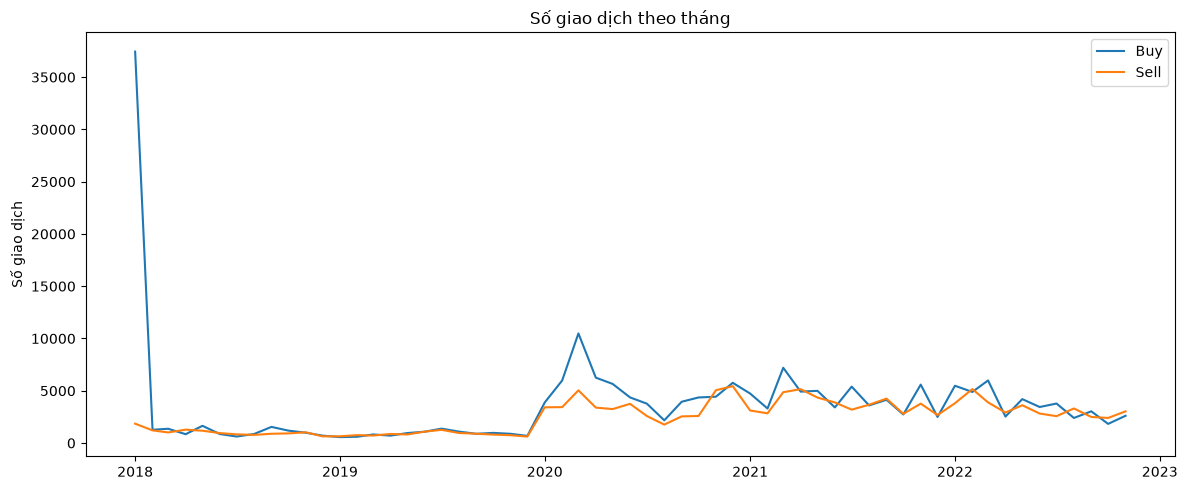

In [19]:
monthly_transactions = (
    transactions.assign(month=transactions["timestamp"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "transactionType"]).size()
    .unstack(fill_value=0).reset_index()
)

display(monthly_transactions.head())
monthly_transactions.to_csv(OUTPUT_DIR / "13_monthly_transactions.csv", index=False)

plt.figure(figsize=(12, 5))
for col in monthly_transactions.columns:
    if col != "month":
        plt.plot(monthly_transactions["month"], monthly_transactions[col], label=col)
plt.title("Số giao dịch theo tháng")
plt.ylabel("Số giao dịch")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_transactions.png", dpi=160, bbox_inches="tight")
plt.show()


## 7. Mức độ hoạt động

In [20]:
customer_activity = (
    transactions.groupby("customerID")
    .agg(
        transaction_count=("transactionID", "nunique"),
        asset_count=("ISIN", "nunique"),
        total_value=("totalValue", "sum"),
        avg_value=("totalValue", "mean"),
        buy_count=("transactionType", lambda x: (x == "Buy").sum()),
        sell_count=("transactionType", lambda x: (x == "Sell").sum()),
    ).reset_index()
)

asset_activity = (
    transactions.groupby("ISIN")
    .agg(
        transaction_count=("transactionID", "nunique"),
        customer_count=("customerID", "nunique"),
        total_value=("totalValue", "sum"),
        avg_value=("totalValue", "mean"),
    ).reset_index().sort_values("transaction_count", ascending=False)
)

activity_summary = pd.DataFrame({
    "Chỉ số": [
        "Trung vị giao dịch/khách hàng",
        "Trung bình giao dịch/khách hàng",
        "Khách hàng chỉ có 1 giao dịch",
        "Khách hàng có <= 3 giao dịch",
        "Trung vị số tài sản/khách hàng",
        "Trung bình khách hàng/tài sản",
    ],
    "Giá trị": [
        customer_activity["transaction_count"].median(),
        customer_activity["transaction_count"].mean(),
        (customer_activity["transaction_count"] == 1).sum(),
        (customer_activity["transaction_count"] <= 3).sum(),
        customer_activity["asset_count"].median(),
        asset_activity["customer_count"].mean(),
    ]
})

display(activity_summary)
display(asset_activity.head(20))

activity_summary.to_csv(OUTPUT_DIR / "14_activity_summary.csv", index=False)
customer_activity.to_csv(OUTPUT_DIR / "15_customer_activity.csv", index=False)
asset_activity.to_csv(OUTPUT_DIR / "16_asset_activity.csv", index=False)


,Chỉ số,Giá trị
0,Trung vị giao dịch/khách hàng,2.00
1,Trung bình giao dịch/khách hàng,12.96
2,Khách hàng chỉ có 1 giao dịch,"4,117.00"
3,Khách hàng có <= 3 giao dịch,"15,950.00"
4,Trung vị số tài sản/khách hàng,1.00
5,Trung bình khách hàng/tài sản,263.71


,ISIN,transaction_count,customer_count,total_value,avg_value
65,GRS003003035,42214,8007,"236,501,097.50","5,602.43"
68,GRS015003007,31495,4427,"151,479,334.73","4,809.63"
67,GRS014003032,22070,2704,"281,336,197.30","12,747.45"
166,GRS323003012,18152,2563,"69,148,003.31","3,809.39"
220,GRS434003000,15939,2513,"93,499,707.64","5,866.10"
197,GRS393503008,11400,2058,"62,646,188.08","5,495.28"
212,GRS419003009,10942,1985,"61,087,734.05","5,582.87"
140,GRS260333000,10591,3290,"46,944,395.82","4,432.48"
154,GRS298343005,7154,2071,"23,321,504.39","3,259.93"
215,GRS426003000,6994,1166,"38,846,823.58","5,554.31"


,Nhóm số giao dịch,Số khách hàng
0,1,4117
1,2–3,11833
2,4–5,3803
3,6–10,3336
4,11–20,1852
5,21–50,1555
6,51–100,616
7,>100,594


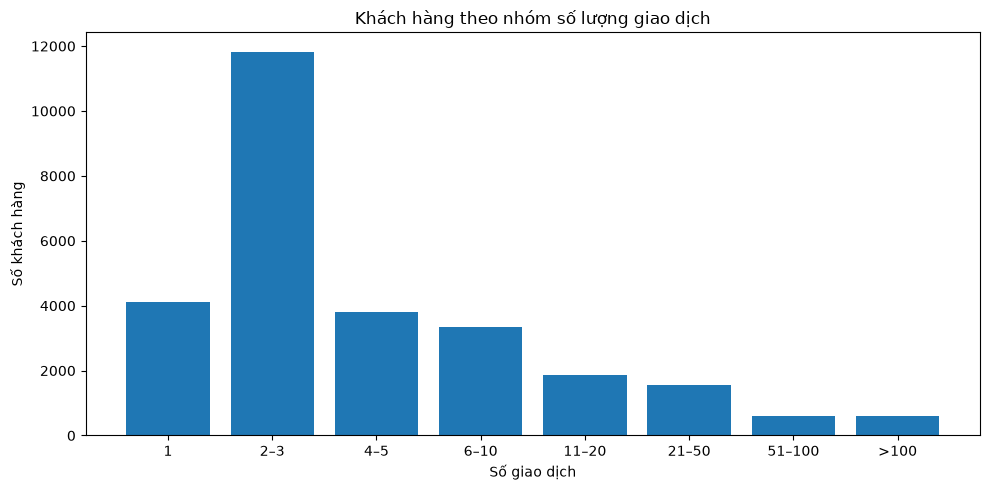

In [21]:
bins = [0, 1, 3, 5, 10, 20, 50, 100, float("inf")]
labels = [
    "1",
    "2–3",
    "4–5",
    "6–10",
    "11–20",
    "21–50",
    "51–100",
    ">100"
]

customer_activity["transaction_group"] = pd.cut(
    customer_activity["transaction_count"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

group_table = (
    customer_activity["transaction_group"]
    .value_counts()
    .sort_index()
    .rename_axis("Nhóm số giao dịch")
    .reset_index(name="Số khách hàng")
)

display(group_table)

plt.figure(figsize=(10, 5))
plt.bar(
    group_table["Nhóm số giao dịch"].astype(str),
    group_table["Số khách hàng"]
)

plt.title("Khách hàng theo nhóm số lượng giao dịch")
plt.xlabel("Số giao dịch")
plt.ylabel("Số khách hàng")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "customer_transaction_groups.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 8. Dữ liệu giá

In [22]:
price_coverage = (
    prices.groupby("ISIN")
    .agg(
        first_date=("timestamp", "min"),
        last_date=("timestamp", "max"),
        price_records=("closePrice", "count"),
        min_price=("closePrice", "min"),
        max_price=("closePrice", "max"),
        avg_price=("closePrice", "mean"),
    ).reset_index()
)

price_summary = pd.DataFrame({
    "Chỉ số": [
        "Số tài sản có dữ liệu giá",
        "Số bản ghi giá",
        "Giá nhỏ nhất",
        "Giá lớn nhất",
        "Giá trung bình",
        "Trung vị số bản ghi giá/tài sản",
    ],
    "Giá trị": [
        prices["ISIN"].nunique(),
        len(prices),
        prices["closePrice"].min(),
        prices["closePrice"].max(),
        prices["closePrice"].mean(),
        price_coverage["price_records"].median(),
    ]
})

display(price_summary)
display(price_coverage.head())

price_summary.to_csv(OUTPUT_DIR / "17_price_summary.csv", index=False)
price_coverage.to_csv(OUTPUT_DIR / "18_price_coverage.csv", index=False)


,Chỉ số,Giá trị
0,Số tài sản có dữ liệu giá,807.00
1,Số bản ghi giá,"703,303.00"
2,Giá nhỏ nhất,0.01
3,Giá lớn nhất,"3,783.50"
4,Giá trung bình,103.59
5,Trung vị số bản ghi giá/tài sản,"1,072.00"


,ISIN,first_date,last_date,price_records,min_price,max_price,avg_price
0,100974271034,2018-01-02,2022-11-29,1278,1.52,5.19,3.55
1,AU3CB0228823,2021-01-27,2022-11-29,480,61.21,71.59,67.15
2,AU3CB0237725,2018-01-02,2020-09-09,700,53.90,65.86,62.89
3,AU3CB0237881,2018-11-22,2020-05-27,393,57.97,69.80,66.87
4,AU3CB0258465,2019-04-12,2022-11-29,946,56.20,70.32,66.26


## 9. So sánh các split train/test

,t,test_end,n_train_transactions,n_test_transactions,n_customers_train,n_customers_test,n_assets_train,n_assets_test,n_train_test_pairs_removed_as_overlap
0,2020-01-01,2020-07-01,30605,19650,2348,2348,241,176,31327
1,2020-07-01,2021-01-01,62537,9542,2214,2214,234,157,32811
2,2021-01-01,2021-07-01,80712,12126,2696,2696,235,176,37930
3,2021-07-01,2022-01-01,110483,10785,3331,3331,249,174,30294
4,2022-01-01,2022-07-01,114290,8559,2593,2593,250,175,39055


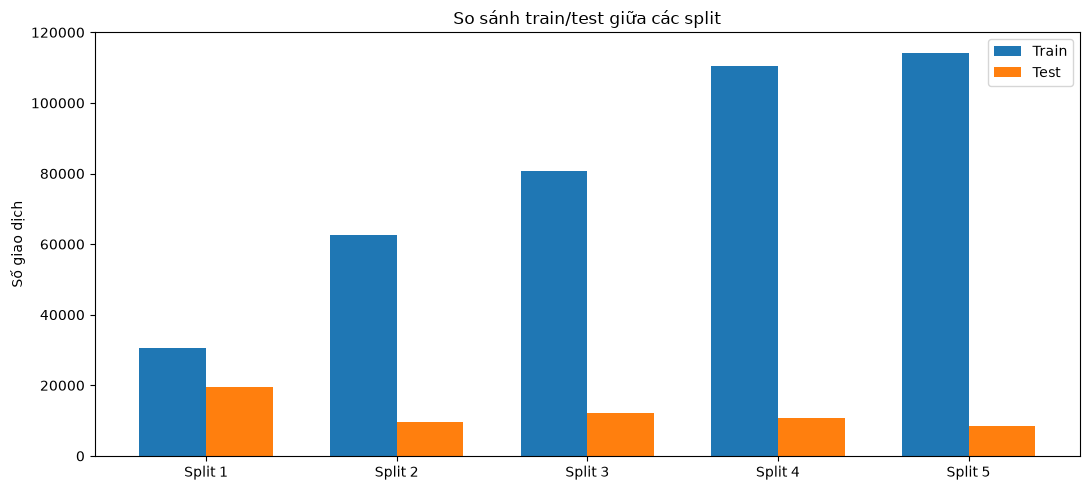

In [23]:
summary_path = DATA_DIR / "split_summary.csv"

if summary_path.exists():
    split_summary = pd.read_csv(summary_path)
else:
    rows = []
    for folder in sorted(DATA_DIR.glob("split_*")):
        train_path = folder / "train_transactions.csv"
        test_path = folder / "test_transactions.csv"
        if not train_path.exists() or not test_path.exists():
            continue
        train = pd.read_csv(train_path)
        test = pd.read_csv(test_path)
        rows.append({
            "split": folder.name,
            "n_train_transactions": len(train),
            "n_test_transactions": len(test),
            "n_customers_train": train["customerID"].nunique(),
            "n_customers_test": test["customerID"].nunique(),
            "n_assets_train": train["ISIN"].nunique(),
            "n_assets_test": test["ISIN"].nunique(),
        })
    split_summary = pd.DataFrame(rows)

display(split_summary)
split_summary.to_csv(OUTPUT_DIR / "19_split_comparison.csv", index=False)

if not split_summary.empty:
    x = np.arange(len(split_summary))
    w = .35
    plt.figure(figsize=(11, 5))
    plt.bar(x-w/2, split_summary["n_train_transactions"], w, label="Train")
    plt.bar(x+w/2, split_summary["n_test_transactions"], w, label="Test")
    plt.xticks(x, [f"Split {i+1}" for i in range(len(split_summary))])
    plt.ylabel("Số giao dịch")
    plt.title("So sánh train/test giữa các split")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "split_train_test_comparison.png", dpi=160, bbox_inches="tight")
    plt.show()


## 10. Bảng chéo hồ sơ khách hàng

In [24]:
risk_capacity_cross = pd.crosstab(
    customer_latest["riskLevel"].fillna("Missing"),
    customer_latest["investmentCapacity"].fillna("Missing"),
    margins=True
)
type_risk_cross = pd.crosstab(
    customer_latest["customerType"].fillna("Missing"),
    customer_latest["riskLevel"].fillna("Missing"),
    margins=True
)

display(Markdown("### Mức rủi ro × Khả năng đầu tư"))
display(risk_capacity_cross)
display(Markdown("### Loại khách hàng × Mức rủi ro"))
display(type_risk_cross)

risk_capacity_cross.to_csv(OUTPUT_DIR / "20_risk_capacity_cross.csv")
type_risk_cross.to_csv(OUTPUT_DIR / "21_customer_type_risk_cross.csv")


### Mức rủi ro × Khả năng đầu tư

investmentCapacity,CAP_30K_80K,CAP_80K_300K,CAP_GT300K,CAP_LT30K,Unknown,All
riskLevel,,,,,,
Aggressive,697,863,287,831,0,2678
Balanced,1955,1788,321,4518,0,8582
Conservative,599,310,16,4746,1,5672
Income,2232,1805,178,7621,2,11838
Unknown,0,0,0,0,320,320
All,5483,4766,802,17716,323,29090


### Loại khách hàng × Mức rủi ro

riskLevel,Aggressive,Balanced,Conservative,Income,Unknown,All
customerType,,,,,,
Inactive,5,27,76,78,22,208
Legal Entity,25,12,0,2,0,39
Mass,976,4419,4967,7970,278,18610
Premium,1296,3477,602,3514,17,8906
Professional,376,647,27,274,3,1327
All,2678,8582,5672,11838,320,29090


## 11. Xuất báo cáo Excel

In [25]:
from pathlib import Path

OUTPUT_DIR = Path("/Users/meomeo/Downloads/Thesis/output/eda_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image

excel_path = OUTPUT_DIR / "Report.xlsx"

# Các bảng sẽ được xuất thành từng sheet
sheets = {
    "Overview": overview,
    "Data Quality": quality_summary,
    "Missing Values": missing_by_column,
    "Customer Type": customer_type,
    "Risk Level": risk_level,
    "Investment Capacity": capacity,
    "Asset Category": asset_category,
    "Asset Sector": asset_sector,
    "Asset Market": asset_market,
    "Transaction Type": transaction_type,
    "Transaction Channel": transaction_channel,
    "Transaction Value": transaction_value_summary,
    "Monthly Transactions": monthly_transactions,
    "Activity Summary": activity_summary,
    "Price Summary": price_summary,
    "Split Comparison": split_summary,
}

# Biểu đồ nào được chèn vào sheet nào
chart_map = {
    "Customer Type": OUTPUT_DIR / "customer_by_type.png",
    "Risk Level": OUTPUT_DIR / "customer_by_risk.png",
    "Investment Capacity": OUTPUT_DIR / "customer_by_capacity.png",
    "Asset Category": OUTPUT_DIR / "asset_by_category.png",
    "Asset Sector": OUTPUT_DIR / "asset_by_sector.png",
    "Asset Market": OUTPUT_DIR / "asset_by_market.png",
    "Monthly Transactions": OUTPUT_DIR / "monthly_transactions.png",
    "Activity Summary": OUTPUT_DIR / "customer_transaction_groups.png",
    "Split Comparison": OUTPUT_DIR / "split_train_test_comparison.png",
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    # Xuất các bảng thông thường
    for sheet_name, df in sheets.items():
        df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

    # Xuất hai bảng chéo
    risk_capacity_cross.to_excel(
        writer,
        sheet_name="Risk x Capacity"
    )

    type_risk_cross.to_excel(
        writer,
        sheet_name="Type x Risk"
    )

    # Format từng sheet
    for sheet_name, ws in writer.sheets.items():

        ws.freeze_panes = "A2"
        ws.sheet_view.showGridLines = False
        ws.auto_filter.ref = ws.dimensions

        # Format tiêu đề
        for cell in ws[1]:
            cell.font = Font(
                bold=True,
                color="FFFFFF"
            )

            cell.fill = PatternFill(
                fill_type="solid",
                fgColor="4F81BD"
            )

            cell.alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True
            )

        # Tự chỉnh độ rộng cột
        for column_cells in ws.columns:

            column_letter = get_column_letter(
                column_cells[0].column
            )

            max_length = 0

            for cell in column_cells:

                value = (
                    ""
                    if cell.value is None
                    else str(cell.value)
                )

                max_length = max(
                    max_length,
                    len(value)
                )

                cell.alignment = Alignment(
                    vertical="top",
                    wrap_text=True
                )

            ws.column_dimensions[column_letter].width = min(
                max_length + 2,
                35
            )

        ws.row_dimensions[1].height = 30

    # Chèn biểu đồ vào đúng sheet
    for sheet_name, image_path in chart_map.items():

        if sheet_name not in writer.sheets:
            print("Không tìm thấy sheet:", sheet_name)
            continue

        if not image_path.exists():
            print("Không tìm thấy ảnh:", image_path)
            continue

        ws = writer.sheets[sheet_name]

        # Đặt biểu đồ bên phải bảng
        chart_column = ws.max_column + 3

        chart_position = ws.cell(
            row=2,
            column=chart_column
        ).coordinate

        img = Image(str(image_path))
        img.width = 650
        img.height = 350

        ws.add_image(
            img,
            chart_position
        )

print("Đã xuất báo cáo Excel:")
print(excel_path.resolve())

Đã xuất báo cáo Excel:
/Users/meomeo/Downloads/Thesis/output/eda_output/Report.xlsx


## 12. Danh sách output

In [27]:
output_files = pd.DataFrame([
    {
        "file": p.name,
        "path": str(p.resolve()),
        "size_kb": round(p.stat().st_size / 1024, 2)
    }
    for p in sorted(OUTPUT_DIR.rglob("*"))
    if p.is_file()
])

display(output_files)
print("Output folder:", OUTPUT_DIR.resolve())


,file,path,size_kb
0,.~FAR_Trans_EDA_Report.xlsx,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.16
1,01_overview.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.39
2,02_data_quality_summary.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.27
3,03_missing_by_column.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.34
4,04_customer_by_type.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.21
5,05_customer_by_risk.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.21
6,06_customer_by_capacity.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.22
7,07_asset_by_category.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.12
8,08_asset_by_sector.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,0.60
9,09_asset_by_market.csv,/Users/meomeo/Downloads/Thesis/output/eda_outp...,1.00


Output folder: /Users/meomeo/Downloads/Thesis/output/eda_output
